In [1]:
import pandas as pd

In [2]:
df=pd.read_excel("Project_2_Customer_Churn_Retention.xlsx")

In [3]:
df.head()

,Customer_ID,Age,Tenure_Months,Plan,Contract_Type,Monthly_Charges,Monthly_Usage_Hours,Support_Tickets,Churn,Customer_Satisfaction
0,CUST0001,24,55,Standard,Annual,866.94,5.4,4,No,9
1,CUST0002,45,36,Standard,Quarterly,4149.55,9.1,3,No,5
2,CUST0003,23,41,Basic,Monthly,4902.43,46.4,2,No,9
3,CUST0004,39,5,Premium,Annual,549.11,16.1,4,Yes,7
4,CUST0005,43,28,Standard,Monthly,1906.21,14.1,2,No,5


In [5]:
df.shape

(700, 10)

In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Tenure_Months', 'Plan', 'Contract_Type',
       'Monthly_Charges', 'Monthly_Usage_Hours', 'Support_Tickets', 'Churn',
       'Customer_Satisfaction'],
      dtype='object')

In [21]:
df.isnull().sum()

Customer_ID              0
Age                      0
Tenure_Months            0
Plan                     0
Contract_Type            0
Monthly_Charges          0
Monthly_Usage_Hours      0
Support_Tickets          0
Churn                    0
Customer_Satisfaction    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dtypes

Customer_ID               object
Age                        int64
Tenure_Months              int64
Plan                      object
Contract_Type             object
Monthly_Charges          float64
Monthly_Usage_Hours      float64
Support_Tickets            int64
Churn                     object
Customer_Satisfaction      int64
dtype: object

In [11]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Monthly_Usage_Hours,Support_Tickets,Customer_Satisfaction
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,42.555714,36.620000,4143.729829,31.085714,3.562857,5.655714
std,13.506679,21.008579,2172.613294,17.081897,2.273261,2.968607
min,20.000000,1.000000,510.850000,2.000000,0.000000,1.000000
25%,31.000000,18.000000,2235.382500,16.375000,2.000000,3.000000
50%,42.000000,37.000000,4161.325000,30.300000,4.000000,6.000000
75%,54.000000,54.250000,5886.657500,46.450000,6.000000,8.000000
max,65.000000,72.000000,7985.060000,59.900000,7.000000,10.000000


In [12]:
df["Churn"].value_counts()

Churn
No     444
Yes    256
Name: count, dtype: int64

In [16]:
churn_rate=(df["Churn"]=="Yes").mean()*100
print(churn_rate)

36.57142857142857


In [17]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     63.428571
Yes    36.571429
Name: proportion, dtype: float64

<Axes: >

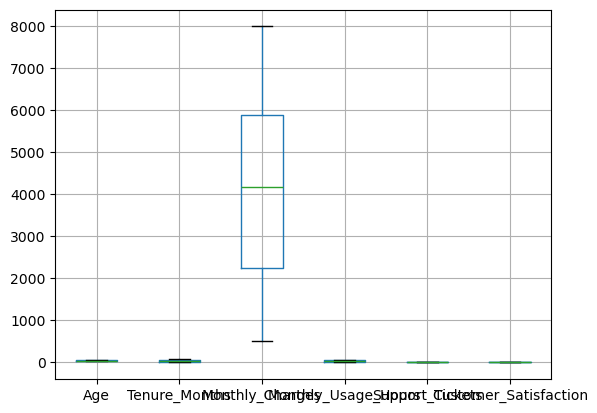

In [19]:
df.boxplot()

In [26]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)

IQR = Q3-Q1

lower=Q1-1.5*IQR
upper= Q3+1.5*IQR

print("LOWER:",lower)
print("UPPER:",upper)      

LOWER: -3.5
UPPER: 88.5


In [28]:
df.groupby("Plan")["Churn"].value_counts()

Plan      Churn
Basic     No       159
          Yes      109
Premium   No        86
          Yes       50
Standard  No       199
          Yes       97
Name: count, dtype: int64

In [29]:
df.groupby("Plan")["Churn"].value_counts(normalize=True)*100

Plan      Churn
Basic     No       59.328358
          Yes      40.671642
Premium   No       63.235294
          Yes      36.764706
Standard  No       67.229730
          Yes      32.770270
Name: proportion, dtype: float64

In [30]:
df["Contract_Type"].unique()

array(['Annual', 'Quarterly', 'Monthly'], dtype=object)

In [31]:
df.groupby("Contract_Type")["Churn"].value_counts()

Contract_Type  Churn
Annual         No       130
               Yes       51
Monthly        No       203
               Yes      170
Quarterly      No       111
               Yes       35
Name: count, dtype: int64

In [33]:
df.groupby("Contract_Type")["Churn"].value_counts(normalize=True)*100

Contract_Type  Churn
Annual         No       71.823204
               Yes      28.176796
Monthly        No       54.423592
               Yes      45.576408
Quarterly      No       76.027397
               Yes      23.972603
Name: proportion, dtype: float64

In [34]:
df.groupby("Customer_Satisfaction")["Churn"].value_counts(normalize=True)*100

Customer_Satisfaction  Churn
1                      No       60.000000
                       Yes      40.000000
2                      No       65.333333
                       Yes      34.666667
3                      No       55.714286
                       Yes      44.285714
4                      No       63.076923
                       Yes      36.923077
5                      No       67.187500
                       Yes      32.812500
6                      No       63.768116
                       Yes      36.231884
7                      No       71.698113
                       Yes      28.301887
8                      No       55.223881
                       Yes      44.776119
9                      No       70.114943
                       Yes      29.885057
10                     No       62.352941
                       Yes      37.647059
Name: proportion, dtype: float64

In [35]:
df["Monthly_Charges"].unique()

array([ 866.94, 4149.55, 4902.43,  549.11, 1906.21, 1146.53, 2373.52,
       1871.58, 1432.13, 1470.94, 3285.44, 1465.53, 6300.66, 3520.87,
       1376.19, 5385.12, 6411.38, 3197.4 ,  546.01, 5376.26, 6154.92,
       7169.68, 5848.64, 4976.34, 3073.13, 2328.75,  986.56, 6644.78,
       4702.28, 2659.22, 1434.87, 2662.71, 6183.38, 2118.43,  890.77,
       3350.36, 3018.57, 5727.8 , 4670.01, 4045.33, 7820.56, 6830.91,
       1461.14, 2362.96, 3645.23, 1036.43, 6186.06, 6261.3 , 2693.19,
       7290.17, 4643.63, 2177.1 , 5161.21, 5544.27, 5881.62, 7785.08,
       7352.33, 3599.57, 3738.69,  675.89, 3631.24, 1828.61, 1401.26,
       6618.84,  663.6 , 1467.93, 5482.73, 4753.89, 3717.72, 6556.87,
       2285.95, 2049.65, 4352.62, 1299.9 , 5668.09, 7512.59, 6585.68,
       7109.06, 1047.13, 3680.26, 7272.05, 6810.23, 4953.44, 5408.14,
       2495.09, 2489.24, 1000.34, 7264.48, 2667.41, 7943.76,  551.21,
       6493.43, 4443.51,  815.16, 5473.92, 5768.43, 5747.12, 5719.48,
       5586.24, 6256

In [36]:
df["Monthly_Charges"].nunique()

700

In [37]:
df["Charge_group"]=pd.cut(df["Monthly_Charges"],bins=3,labels=["LOW","MEDIUM","HIGH"])

In [38]:
df["Charge_group"].value_counts()

Charge_group
LOW       252
HIGH      227
MEDIUM    221
Name: count, dtype: int64

In [39]:
df["Charge_group"].value_counts(normalize=True)*100

Charge_group
LOW       36.000000
HIGH      32.428571
MEDIUM    31.571429
Name: proportion, dtype: float64

In [40]:
df["Charge_group"].value_counts().sort_index()

Charge_group
LOW       252
MEDIUM    221
HIGH      227
Name: count, dtype: int64

In [42]:
df.corr(numeric_only=True)

,Age,Tenure_Months,Monthly_Charges,Monthly_Usage_Hours,Support_Tickets,Customer_Satisfaction
Age,1.000000,0.029397,-0.072053,-0.010088,0.004196,0.003637
Tenure_Months,0.029397,1.000000,-0.036619,-0.047568,-0.058182,0.025472
Monthly_Charges,-0.072053,-0.036619,1.000000,0.029342,-0.007447,-0.003529
Monthly_Usage_Hours,-0.010088,-0.047568,0.029342,1.000000,-0.048954,0.025714
Support_Tickets,0.004196,-0.058182,-0.007447,-0.048954,1.000000,-0.033781
Customer_Satisfaction,0.003637,0.025472,-0.003529,0.025714,-0.033781,1.000000


In [46]:
churn_rate=(df["Churn"] =="Yes").mean()*100
print("Churn Rate:", churn_rate)


Churn Rate: 36.57142857142857


In [48]:
retention_rate=(df["Churn"]=="No").mean()*100
print("Retention Rate:",retention_rate)

Retention Rate: 63.42857142857142
